# High-dimensional Data

```{contents}
:local:
:depth: 2
```

:::{admonition} Learning Objectives
:class: tip

- Explain the “curse of dimensionality” and why high-dimensional feature spaces complicate model fitting and generalization.
- Visualize multivariate feature relationships and identify collinearity using plots and summary statistics.
- Standardize and transform features and targets appropriately; justify when scaling is required.
:::

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('../settings/plot_style.mplstyle')

## High-dimensional Data

So far we have only worked with datasets that have a single input dimension. We have generated "features" from this dimension, but we have not considered the case of a problem where multiple inputs are given. This is a very common scenario, and one of the main advantages of many machine-learning methods is that they work well for "high-dimesional" data, or data with many features.

In this lecture we will work with a dataset of chemical process data provided by Dow Chemical. The data comes from a generic chemical process with the following setup:

```{figure} images/dow_process.png
:width: 800px
:align: center

Chemical process diagram for the distillation process used in the Dow process dataset.
```
Since this is a proprietary process, we do not have any details of the chemical process, but this is real data that was measured from an actual operating process.


The dataset contains a number of operating conditions for each of the units in the process, as well as the concentration of impurities in the output stream. Let's take a look:

In [2]:
import pandas as pd
import numpy as np

df = pd.read_excel('data/impurity_dataset-training.xlsx')
df.head(10) #<- shows the first 10 entries

,Date,x1:Primary Column Reflux Flow,x2:Primary Column Tails Flow,x3:Input to Primary Column Bed 3 Flow,x4:Input to Primary Column Bed 2 Flow,x5:Primary Column Feed Flow from Feed Column,x6:Primary Column Make Flow,x7:Primary Column Base Level,x8:Primary Column Reflux Drum Pressure,x9:Primary Column Condenser Reflux Drum Level,...,x36: Feed Column Recycle Flow,x37: Feed Column Tails Flow to Primary Column,x38: Feed Column Calculated DP,x39: Feed Column Steam Flow,x40: Feed Column Tails Flow,Avg_Reactor_Outlet_Impurity,Avg_Delta_Composition Primary Column,y:Impurity,Primary Column Reflux/Feed Ratio,Primary Column Make/Reflux Ratio
0,2015-12-01 00:00:00,327.813,45.7920,2095.06,2156.01,98.5005,95.4674,54.3476,41.0121,52.2353,...,62.8707,45.0085,66.6604,8.68813,99.9614,5.38024,1.49709,1.77833,3.32803,0.291226
1,2015-12-01 01:00:00,322.970,46.1643,2101.00,2182.90,98.0014,94.9673,54.2247,41.0076,52.5378,...,62.8651,45.0085,66.5496,8.70683,99.8637,5.33345,1.51392,1.76964,3.29556,0.294044
2,2015-12-01 02:00:00,319.674,45.9927,2102.96,2151.39,98.8229,96.0785,54.6130,41.0451,52.0159,...,62.8656,45.0085,66.0599,8.69269,100.2490,5.37677,1.50634,1.76095,3.23481,0.300552
3,2015-12-01 03:00:00,327.223,46.0960,2101.37,2172.14,98.7733,96.1223,54.9153,41.0405,52.9477,...,62.8669,45.0085,67.9697,8.70482,100.3200,5.32315,1.47935,1.75226,3.31287,0.293752
4,2015-12-01 04:00:00,331.177,45.8493,2114.06,2157.77,99.3231,94.7521,54.0925,40.9934,53.0507,...,62.8673,45.0085,67.6454,8.70077,100.6590,5.28227,1.44489,1.74357,3.33435,0.286107
5,2015-12-01 05:00:00,328.884,46.0729,2100.26,2134.76,99.3376,95.4188,53.9989,41.0217,53.0389,...,62.8690,45.0085,67.6828,8.69795,100.8260,5.28510,1.51144,1.73488,3.31077,0.290129
6,2015-12-01 06:00:00,327.335,46.0581,2101.57,2191.37,98.9044,94.9811,54.0685,41.0499,52.8279,...,62.8720,45.0085,66.0828,8.70780,100.3580,5.35512,1.51096,1.72619,3.30961,0.290165
7,2015-12-01 07:00:00,329.935,45.9708,2099.27,2133.95,99.6756,94.8352,54.0001,40.9886,52.7697,...,62.8694,45.0085,67.5438,8.69391,101.1360,5.31343,1.51180,1.71750,3.31009,0.287436
8,2015-12-01 08:00:00,329.128,45.8875,2099.12,2055.11,98.8823,95.0573,53.9876,41.0169,52.8802,...,62.8690,45.0085,66.9394,8.70810,100.3630,5.35183,1.48168,1.70881,3.32848,0.288816
9,2015-12-01 09:00:00,327.686,45.8192,2109.75,2185.82,98.8448,95.5414,54.0806,41.0029,53.0875,...,62.8690,45.0085,65.5845,8.69685,100.2790,5.31385,1.51268,1.70012,3.31516,0.291564


In order to work with this data we need to "clean" it to remove missing values. We will come back to this in the "data management" module. For now, just run the cell below and it will create a matrix `X` of inputs and `y` of impurity concentrations:

In [3]:
def is_real_and_finite(x):
    # used to determine if an entry is a real, finite number.
    if not np.isreal(x):
        return False
    elif not np.isfinite(x):
        return False
    else:
        return True

all_data = df[df.columns[1:]].values #drop the first column (date)
numeric_map = df[df.columns[1:]].map(is_real_and_finite)
real_rows = numeric_map.all(axis=1).copy().values #True if all values in a row are real numbers
X = np.array(all_data[real_rows,:-5], dtype='float') #drop the last 5 cols that are not inputs
y = np.array(all_data[real_rows,-3], dtype='float')
y = y.reshape(-1,1)
print(X.shape, y.shape)

(10297, 40) (10297, 1)


This is the dataset we will work with. We have 10297 data points, with 40 input variables (features) and one output variable. We can pull the names of the features (and output) in case we forget later:

In [4]:
x_names = [str(x) for x in df.columns[1:41]]
y_name = str(df.columns[-3])
print(y_name)
x_names

y:Impurity


['x1:Primary Column Reflux Flow',
 'x2:Primary Column Tails Flow',
 'x3:Input to Primary Column Bed 3 Flow',
 'x4:Input to Primary Column Bed 2 Flow',
 'x5:Primary Column Feed Flow from Feed Column',
 'x6:Primary Column Make Flow',
 'x7:Primary Column Base Level',
 'x8:Primary Column Reflux Drum Pressure',
 'x9:Primary Column Condenser Reflux Drum Level',
 'x10:Primary Column Bed1 DP',
 'x11:Primary Column Bed2 DP',
 'x12:Primary Column Bed3 DP',
 'x13:Primary Column Bed4 DP',
 'x14:Primary Column Base Pressure',
 'x15:Primary Column Head Pressure',
 'x16:Primary Column Tails Temperature',
 'x17:Primary Column Tails Temperature 1',
 'x18:Primary Column Bed 4 Temperature',
 'x19:Primary Column Bed 3 Temperature',
 'x20:Primary Column Bed 2 Temperature',
 'x21:Primary Column Bed 1 Temperature',
 'x22: Secondary Column Base Concentration',
 'x23: Flow from Input to Secondary Column',
 'x24: Secondary Column Tails Flow',
 'x25: Secondary Column Tray DP',
 'x26: Secondary Column Head Pressu

Don't worry if all this code doesn't make sense, we will revisit `pandas` in more detail later. All you need to know for now is that it cleans the data and reads it from the Excel spreadsheet into a `numpy` array. 

In this section, the goal is to predict the output, impurity, as a function of all the input variables. Notably, in reality this data comes from a time series, which means that there are internal correlations as we will discuss more in the "time series" topic. However, for now we will (incorrectly) assume that the data are "independent", meaning that we can shuffle the data points and treat them as random samples.

:::{exercise}
:label: ex-reg-feat-extract

Write a function that takes three arguments: a desired feature name (a string), a list of feature names (e.g. `x_names`), and a data matrix (e.g. `X`). The function should select the desired feature name from the data matrix and return it as a 1-dimensional `numpy` array.

:::


## Visualization of features

Unlike working with a single variable where we can plot "x vs. y," it is harder to build intuition for **higher-dimensional** data because we cannot directly visualize all dimensions at once. A good first step is to look at histograms of each input variable:

X dimensions: (10297, 40)
Feature names: ['x1:Primary Column Reflux Flow', 'x2:Primary Column Tails Flow', 'x3:Input to Primary Column Bed 3 Flow', 'x4:Input to Primary Column Bed 2 Flow', 'x5:Primary Column Feed Flow from Feed Column', 'x6:Primary Column Make Flow', 'x7:Primary Column Base Level', 'x8:Primary Column Reflux Drum Pressure', 'x9:Primary Column Condenser Reflux Drum Level', 'x10:Primary Column Bed1 DP', 'x11:Primary Column Bed2 DP', 'x12:Primary Column Bed3 DP', 'x13:Primary Column Bed4 DP', 'x14:Primary Column Base Pressure', 'x15:Primary Column Head Pressure', 'x16:Primary Column Tails Temperature', 'x17:Primary Column Tails Temperature 1', 'x18:Primary Column Bed 4 Temperature', 'x19:Primary Column Bed 3 Temperature', 'x20:Primary Column Bed 2 Temperature', 'x21:Primary Column Bed 1 Temperature', 'x22: Secondary Column Base Concentration', 'x23: Flow from Input to Secondary Column', 'x24: Secondary Column Tails Flow', 'x25: Secondary Column Tray DP', 'x26: Secondary Co

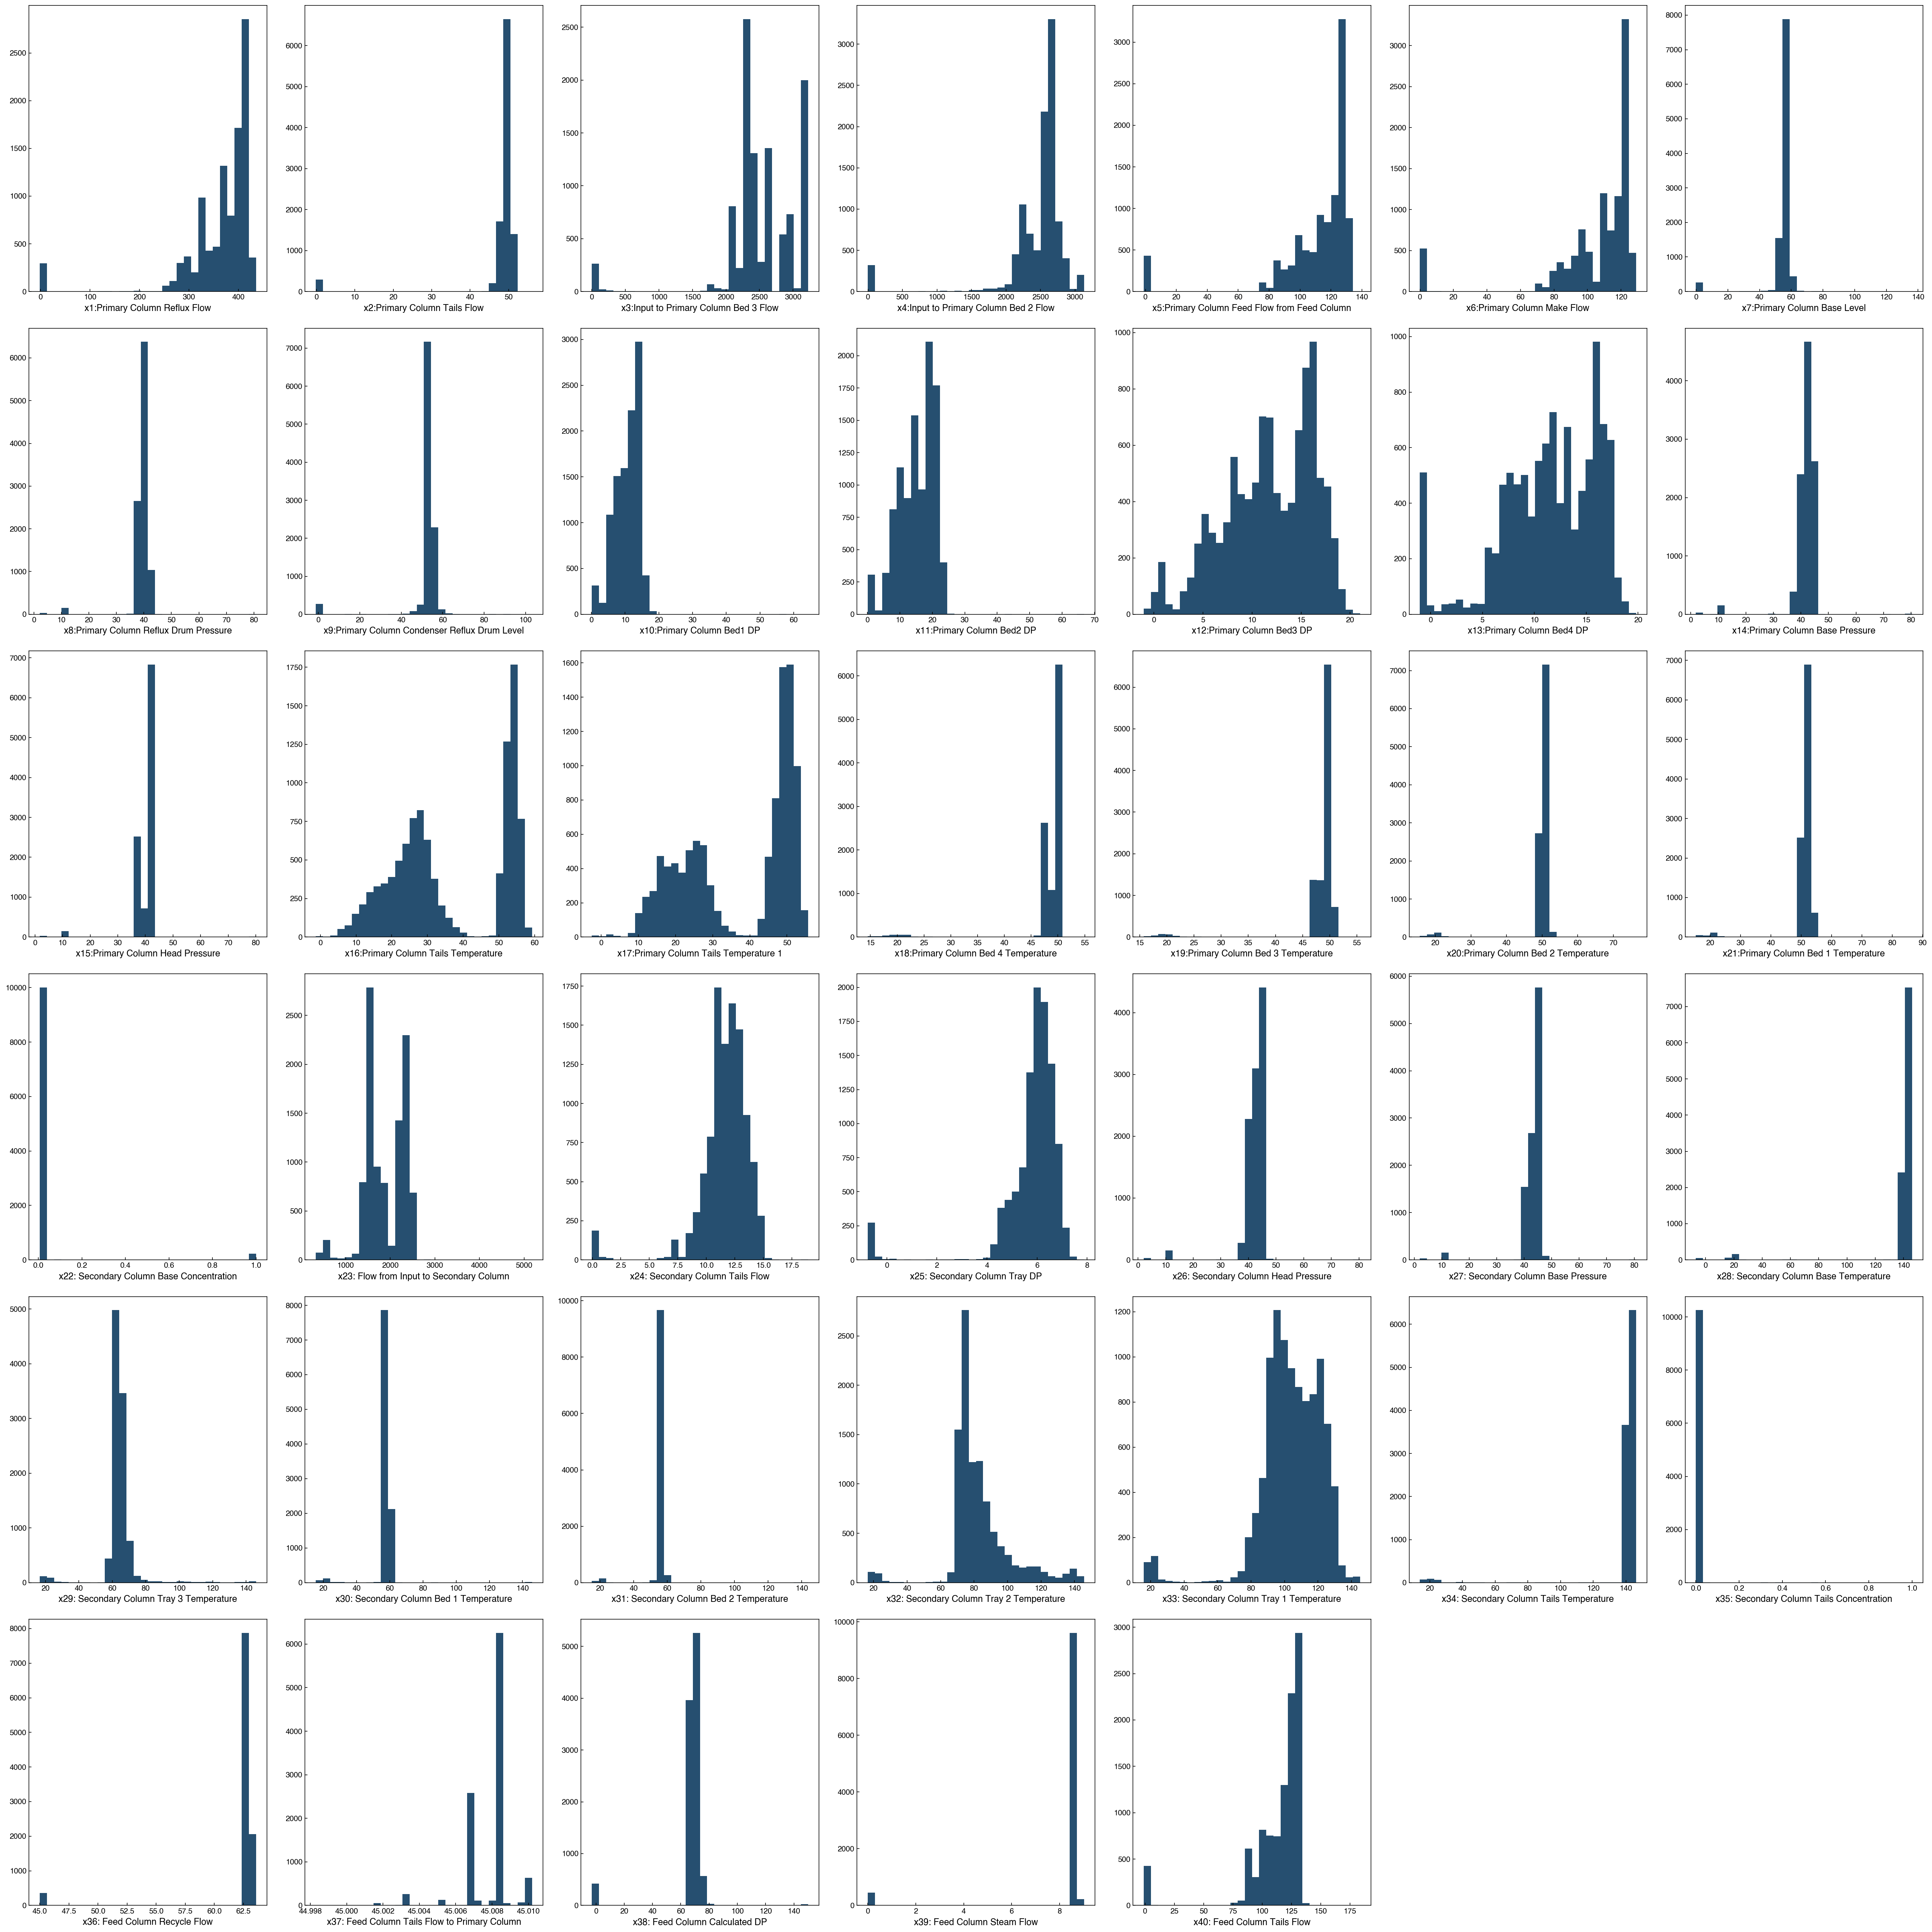

In [5]:
print(f'X dimensions: {X.shape}')
print(f'Feature names: {x_names}')

N = X.shape[-1]
n = int(np.sqrt(N))
fig, axes = plt.subplots(n, n + 1, figsize=(6*n, 6*n))
ax_list = axes.ravel()

for i in range(N):
    ax_list[i].hist(X[:, i], bins=30, alpha=0.85)
    ax_list[i].set_xlabel(x_names[i])

# Hide any unused axes (if grid has extra panels)
for j in range(N, len(ax_list)):
    ax_list[j].set_visible(False)

plt.tight_layout()

We can see that some features are approximately normally distributed, while others have obvious outliers or bimodal shapes.

```{note}
**Why might there be bimodal distributions in a chemical process?**  
Chemical processes often operate in distinct modes. For example, equipment may be "on" vs. "off," or a plant may switch among steady-state setpoints (e.g., different product grades, feedstocks, or throughput targets). Such regime changes naturally yield bimodal (or multimodal) feature distributions.
```


### Visualizing two features at a time and other first-pass strategies

A simple next step after histograms is to examine **bivariate** relationships:

- **Scatter plots** for selected feature pairs.
- **Color by the target** (`y`) to see how the response varies in the plane.
- **Small multiples** (pairwise grid) for a *subset* of features when `N` is large.

Here is an example that will plot two features:

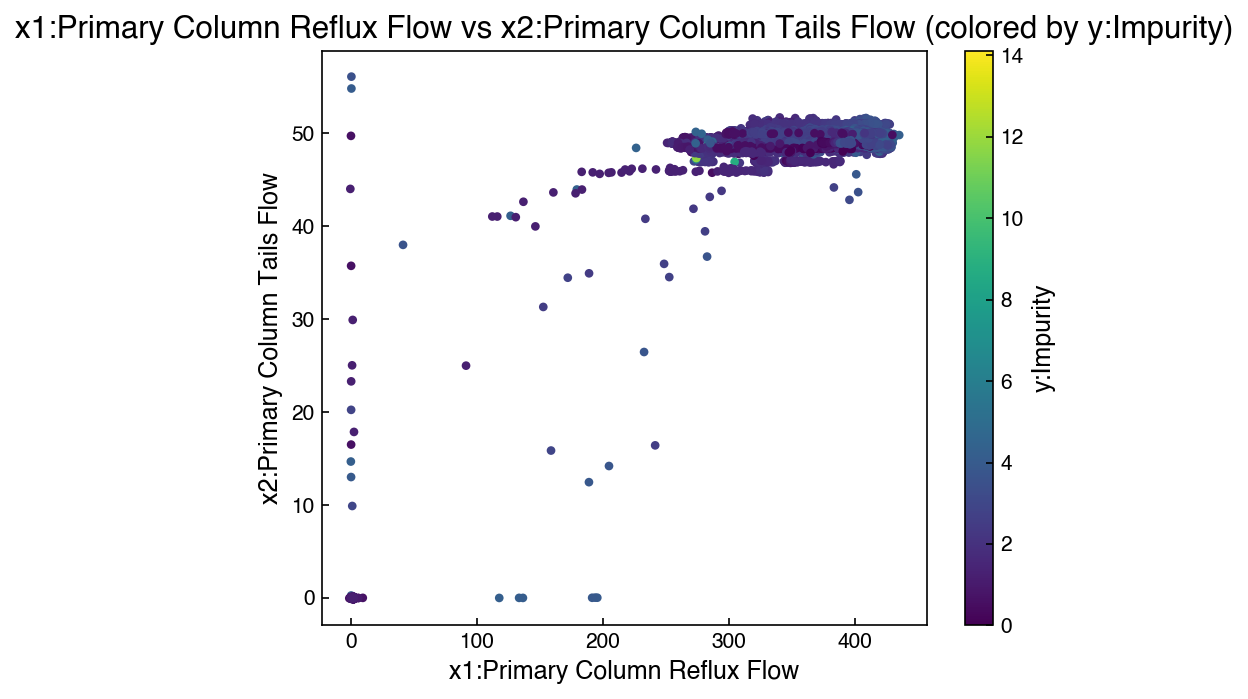

In [6]:
# Pick two features to compare
i, j = 0, 1  # change indices to explore other pairs

plt.figure(figsize=(6,5))
sc = plt.scatter(X[:, i], X[:, j], c=y.ravel(), s=10)
plt.xlabel(x_names[i]); plt.ylabel(x_names[j])
plt.title(f'{x_names[i]} vs {x_names[j]} (colored by {y_name})')
cbar = plt.colorbar(sc); cbar.set_label(y_name)
plt.tight_layout()

It is not practical to visualize an entire 40 x 40 grid, but we can select a small subset:

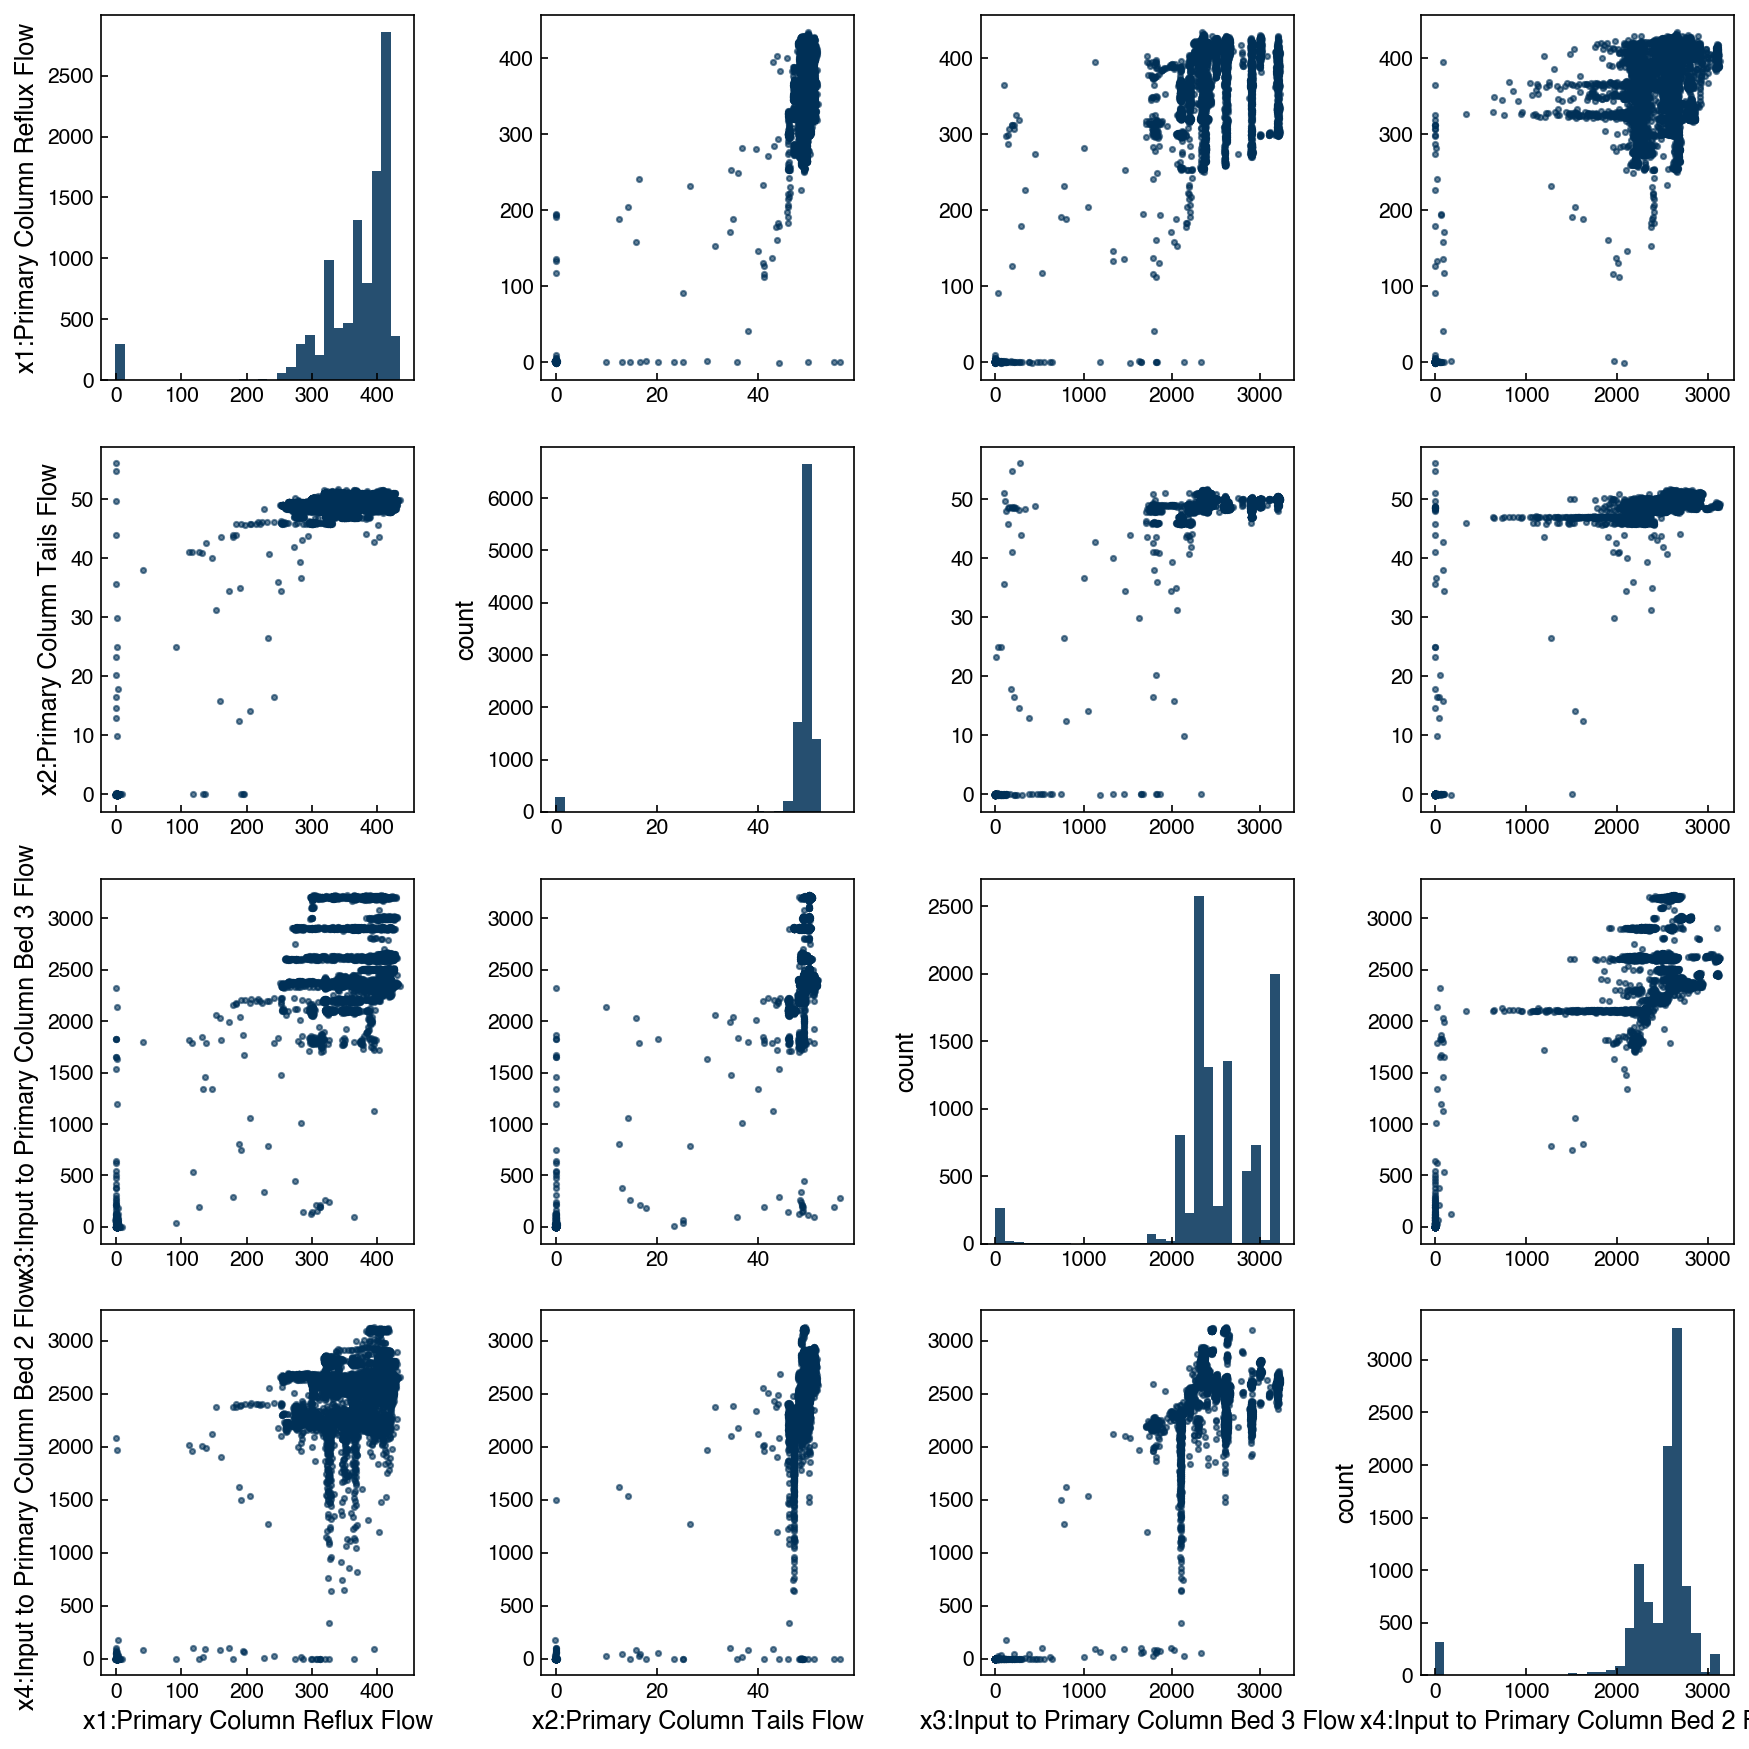

In [7]:
# Small pair grid for a handful of features
subset_idx = [0, 1, 2, 3]  # choose a small set to keep plots readable
m = len(subset_idx)
fig, axes = plt.subplots(m, m, figsize=(3*m, 3*m))

for r, ii in enumerate(subset_idx):
    for c, jj in enumerate(subset_idx):
        ax = axes[r, c]
        if r == c:
            ax.hist(X[:, ii], bins=30, alpha=0.85)
            ax.set_ylabel('count')
        else:
            ax.scatter(X[:, jj], X[:, ii], s=6, alpha=0.6)
        if r == m-1: ax.set_xlabel(x_names[jj])
        if c == 0:   ax.set_ylabel(x_names[ii])

plt.tight_layout()

At this point, nothing really jumps out in terms of correlation with the target variable, but we can still see some interesting aspects of the dataset's structure. For example, it is even more clear from this plot that some variables (e.g. `Input to Primary Column Bed`) have some discrete values, but also vary continuously in general. This is consistent with a chemical process that has several operating "set points" where it typically runs, but it is also sometimes operated at conditions outside the typical ones.
### Covariance and correlation matrices

We can also look for feature relationships through the **covariance matrix**. The covariance describes how features vary together. We will not go through the math here, but we will discuss the concepts:

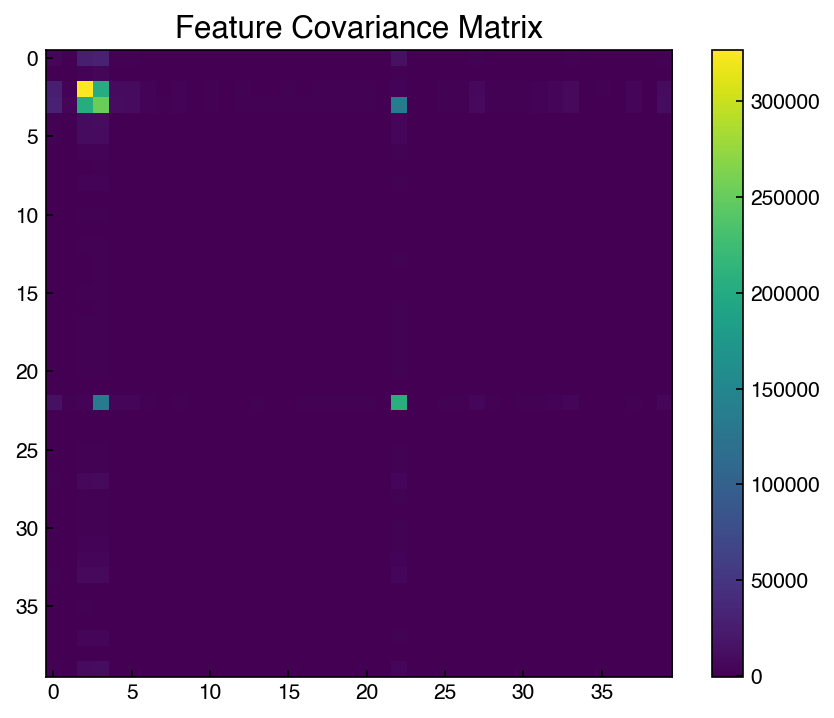

In [8]:
covar = np.cov(X.T)
fig, ax = plt.subplots(figsize=(6,5))
c = ax.imshow(covar)
ax.set_title('Feature Covariance Matrix')
fig.colorbar(c);
plt.tight_layout()

This matrix suggests that some features are highly correlated. We can inspect specific entries:

In [9]:
# Diagonal entries are variances (depend on scale); off-diagonals are covariances.
print(f'Variance of {x_names[2]}: {covar[2,2]:.3g}')
print(f'Variance of {x_names[1]}: {covar[1,1]:.3g}')
# Uncomment to inspect an off-diagonal covariance:
print(f'Covariance({x_names[2]}, {x_names[3]}): {covar[2,3]:.3g}')

Variance of x3:Input to Primary Column Bed 3 Flow: 3.26e+05
Variance of x2:Primary Column Tails Flow: 69.6
Covariance(x3:Input to Primary Column Bed 3 Flow, x4:Input to Primary Column Bed 2 Flow): 2.02e+05


These numbers are difficult to compare across features because **covariance depends on units/scale** (e.g., °C vs. bar). A scale-invariant alternative is the **correlation** matrix, which rescales by standard deviations and lies in [-1, 1]:

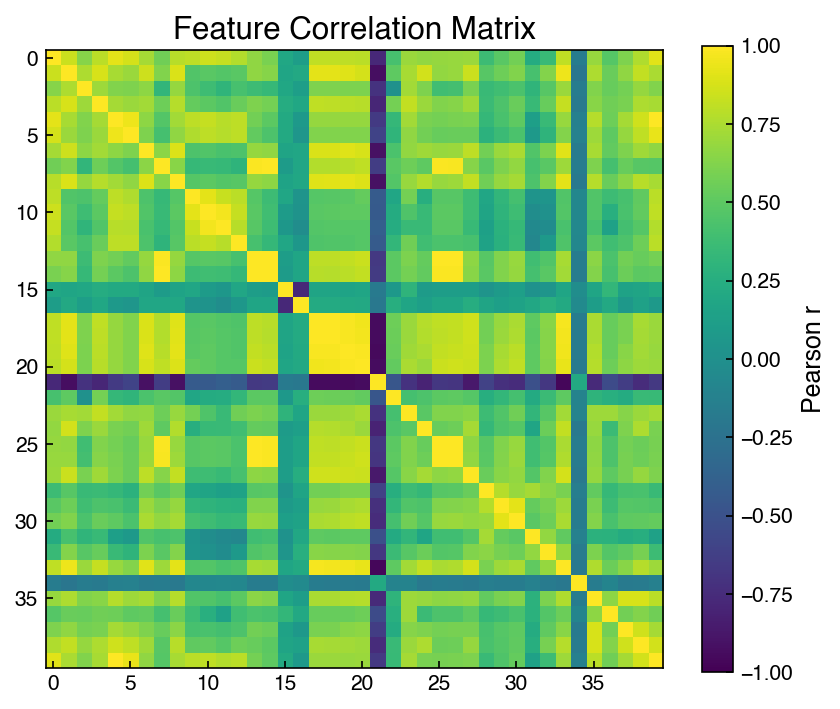

In [10]:
corr = np.corrcoef(X.T)
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix')
fig.colorbar(im, ax=ax, label='Pearson r')
plt.tight_layout()

We will see how these two matrices are related shortly.

:::{exercise}
:label: ex-reg-bivar-corr

1. Programmatically find the top 5 **absolute** correlations among **distinct** feature pairs (ignore the diagonal).
2. Make bivariate scatter plots for those 5 pairs (use small markers and `alpha=0.5`). Color each scatter by `y` to see whether the strongest feature–feature correlations also correspond to structure in the target.

:::

## Scaling Features and Outputs

From the visualization and covariance matrix we can see that different features have very different ranges, and different units (e.g., degrees, percent, count). Scaling data is like "non-dimensionalizing" or normalizing for different units. This is often critical to ensure that certain variables are not weighted more than others.

Statistical methods do not know about physical units, so we can normalize or "scale" features to aid in comparison:

- rescaling: 0 = min, 1 = max
- mean scaling: 0 = mean, 1 = max, -1 = min
- **standard scaling: 0 = mean, 1 = standard deviation**
- unit vector: the length of each multi-dimensional vector is 1

We will typically default to **standard scaling** in this course since it has some nice properties, but you can see the [scikit-learn documentation](http://scikit-learn.org/stable/modules/preprocessing.html) for more examples and discussion.

Note that scaling is not always a good idea. Sometimes the data have units that are already consistent, or rescaling can remove important aspects of the data. Figuring out the best scaling scheme is often achieved through trial and error.

```{note}
The term "scaling" is common throughout science and engineering and has many different meanings. For example, in chemical engineering we often talk about "scaling" a process up, and in physics quantities are sometimes said to "scale" if they are proportional, leading to "scaling relationships". Even within computer science, "scaling" means different things -- the way an algorithm "scales" refers to how much time it takes as the size of the problem or the size of the computer changes. The term "feature scaling" is less ambiguous, and can also be referred to as "feature normalization".
```

It is also important to note that feature scaling is a common source of **data leakage**. Data leakage occurs when information from the testing set "leaks" into the training data, which can lead to artificially good results when the model is applied to the test set. It might seem like feature scaling is not really a "model", but in reality you are using the data to determine the parameters (mean, min, max, or standard deviation) for the scaling. It is important that you always perform any data splitting for cross validation **before** performing feature scaling, and you should only use the training data to determine the scaling parameters. When applying the feature scaling to the testing data, you will still use the parameters (e.g., mean, min, max, or standard deviation) from the training data. Think of an application scenario where you train a model to a large amount of data, but then want to apply it to a single new data point: you would not be able to calculate the mean, min, max, or standard deviation of that data point, so you would need to use the statistics of the training data instead.

In the case of the Dow chemical process data, we can look at the features and see they clearly have different units and different ranges. For example, feature 1 (Primary column tails flow) ranges from 0 to 50, and feature 2 (Input to primary column Bed 3 Flow) ranges from 0 to \~3000. While we do not necessarily know the units (since this is proprietary data), we can see that there is a difference of range. This is why the covariance matrix did not make much sense. We can rescale the data to put everything on similar scales.

First, let's do this manually:

In [11]:
X_scaled_manual = (X - X.mean(axis=0))/X.std(axis=0)
print("Minimum: {}, Maximum: {}".format(X.min(), X.max()))
print("Minimum scaled: {}, Maximum scaled: {}".format(X_scaled_manual.min(), X_scaled_manual.max()))

Minimum: -6.91425, Maximum: 5176.74
Minimum scaled: -8.12009681442378, Maximum scaled: 38.10583689480496


It is also possible to do this with `scikit-learn`:

In [12]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(X) # "fit" the scaler (finds the mean and standard deviation of the data)
X_scaled = ss.transform(X) #"transform" the data by applying the standard scaler

print("Minimum scaled: {}, Maximum scaled: {}".format(X_scaled.min(), X_scaled.max()))

Minimum scaled: -8.12009681442378, Maximum scaled: 38.10583689480496


The `fit` and `transform` methods may seem unintuitive or unnecessarily complex, but this standard interface to `scikit-learn` models makes it possible to "chain" them together and use them interchangeably. We will see an example of this shortly as we create a "pipeline".

```{note}
**What could go wrong with min-max or mean scaling?**  

Min–max and mean scaling can be **highly sensitive to outliers**. A single extreme value can dominate the min/max (or mean) and compress most of the other data into a narrow interval, making patterns hard to see and potentially hurting model performance. Min-max scaling is a good option if your data are guaranteed to be within a certain range, and robust alternatives include standard scaling or scaling with quantiles or medians.
```

Now let's take a look at the covariance matrix with the rescaled data::

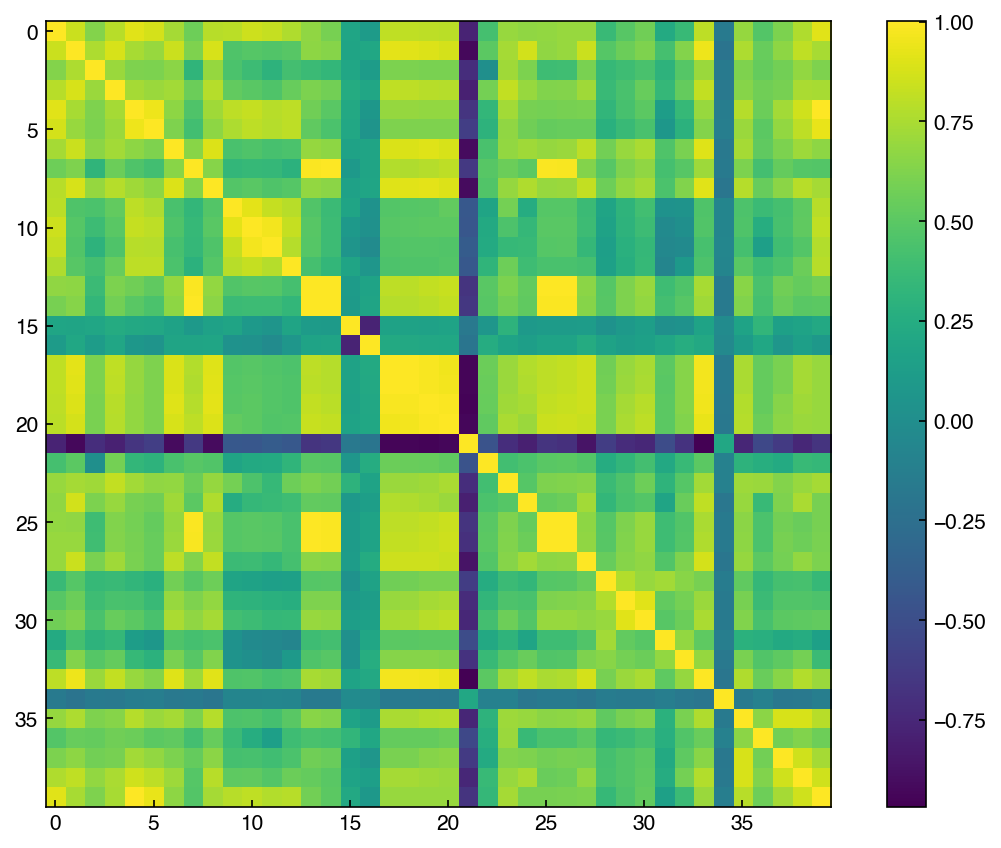

In [13]:
covar = np.cov(X_scaled.T)
fig,ax = plt.subplots()
c = ax.imshow(covar)
fig.colorbar(c);

The structure looks totally different! This is the "correlation matrix", which tells us how correlated different features are on a scale of -1 to 1. A correlation of -1 means they are perfectly anti-correlated, while 1 means they are perfectly correlated. If any features are perfectly (anti)correlated (correlation = 1 or -1) then they are linearly dependent (and won't count toward the rank).

In [14]:
# Maximum entry in convariance
print(f"max entry in covariance matrix: {np.abs(covar).max():.3f}")

max entry in covariance matrix: 1.000


We see that the maximum is 1, which suggests some features are perfectly correlated.

In [15]:
np.linalg.matrix_rank(X)

np.int64(40)

However, we see that the rank is 40, equal to the number of columns, suggesting that the data is full rank. The reason is that the diagonal entries of the standardized covariance (i.e., correlation) matrix will always be 1 since features are perfectly correlated with themselves. We see that the maximum off-diagonal is less than one (although barely), so no **different features** are perfectly correlated. This means the matrix should be full rank, and the sanity check passes.

In [16]:
# Maximum off-diagonal entry of the covariance/correlation matrix

off_diags = []
N = covar.shape[0]

max_offdiag = -1 #set to a number that must be smaller than the smallest real number
i_max = 0
j_max = 0
for i in range(N):
    for j in range(N):
        if i > j:
            entry = np.abs(covar[i,j])
            if entry > max_offdiag: #must be true on first iteration!
                max_offdiag = entry
                i_max = i
                j_max = j
            off_diags.append(np.abs(covar[i,j]))

print(f"max off-diagonal covariance: {max_offdiag:.5f} at ({x_names[i_max]}, {x_names[j_max]}) [indices: {i_max}, {j_max}]")

max off-diagonal covariance: 0.99954 at (x27: Secondary Column Base Pressure, x26: Secondary Column Head Pressure) [indices: 26, 25]


In general, if the data have been **standard scaled** (with the same ddof convention!), then the covariance matrix will range from -1 to 1 and is equivalent to a correlation matrix, which can also be computed directly from the data:

In [17]:
corr = np.corrcoef(X.T)
covar = np.cov(X_scaled.T)
np.isclose(corr, covar, atol=1e-4).all()

np.True_

We will discuss the covariance/correlation matrix much more later, but when dealing with multi-dimensional data it is always good to check.


:::{exercise}
:label: ex-reg-scale-compare

1. Split `X, y` into train/test (80/20) with `random_state=0`.
2. Fit a `StandardScaler` **only on the training set**, then transform both train and test.
3. Confirm that the **training** features have mean=0 and std=1 (per feature). 
4. Check the mean and standard deviation on the **testing** features. Are they exactly equal to zero and one?
:::

## Summary

- High-dimensional datasets should be explored through histograms, bivariate scatter plots, and correlation matrices before any modeling.
- **Standard scaling** normalizes features to zero mean and unit variance; always fit the scaler on training data only to prevent leakage.

## Additional Reading

- Hastie, Tibshirani, & Friedman (2009). *The Elements of Statistical Learning*, 2nd ed., Ch. 18 (High-Dimensional Problems). [Available online](https://hastie.su.domains/ElemStatLearn/)
- [scikit-learn: Preprocessing Documentation](https://scikit-learn.org/stable/modules/preprocessing.html) — Official guide to feature scaling and normalization.
- [Seaborn Statistical Data Visualization](https://seaborn.pydata.org/tutorial.html) — Practical guide to pairplots, heatmaps, and distribution plots for exploratory analysis.